> **Dependencies**: TensorFlow ≥ 2.12, TensorFlow-Probability ≥ 0.20.
>
> **Codebase**: requires `advanced_particle_filter` extracted at `/content/advanced_particle_filter/`. The notebook uses the operator-training subpackage at `dpf_pretrained/mgn_ot_operator/`.
>
> **Drive paths used**: `MyDrive/mgn_ot_operator/data/` for precomputed Sinkhorn targets and `MyDrive/mgn_ot_operator/checkpoints_option_b/` for training checkpoints. If precomputed targets exist on Drive they are reused; otherwise precompute runs from scratch (~30-60 min on A100).
>
> **What it does**: Trains the amortized OT operator (coupling-predictor) on precomputed Sinkhorn targets, validates on held-out data, and benchmarks the resulting forward speedup vs direct Sinkhorn.

---

# Option B: Coupling-Predictor Operator


## 1. Environment setup


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os, zipfile, sys
from google.colab import files

ZIP_NAME_HINT = 'advanced_particle_filter_clean.zip'
LOCAL_PKG_DIR = '/content/advanced_particle_filter'
DRIVE_ZIP_CACHE = f'/content/drive/MyDrive/{ZIP_NAME_HINT}'

if os.path.isdir(LOCAL_PKG_DIR):
    print(f'Package already at {LOCAL_PKG_DIR}')
elif os.path.exists(DRIVE_ZIP_CACHE):
    print(f'Using cached zip: {DRIVE_ZIP_CACHE}')
    with zipfile.ZipFile(DRIVE_ZIP_CACHE, 'r') as zf:
        zf.extractall('/content')
else:
    print(f'Upload {ZIP_NAME_HINT}')
    uploaded = files.upload()
    zip_name = list(uploaded.keys())[0]
    with zipfile.ZipFile(zip_name, 'r') as zf:
        zf.extractall('/content')
    os.makedirs(os.path.dirname(DRIVE_ZIP_CACHE), exist_ok=True)
    import shutil; shutil.copy(zip_name, DRIVE_ZIP_CACHE)

# Add the consolidated mgn_ot_operator subpackage to sys.path so that the
# notebook's bare `from training.X`, `from data.X`, etc. imports resolve.
OPERATOR_PKG = os.path.join(LOCAL_PKG_DIR, 'dpf_pretrained', 'mgn_ot_operator')
if OPERATOR_PKG not in sys.path:
    sys.path.insert(0, OPERATOR_PKG)

from models.operator_b import CouplingOperator
print('CouplingOperator imported.')


Using cached zip: /content/drive/MyDrive/mgn_ot_operator/mgn_ot_operator.zip
CouplingOperator imported.


In [3]:
from config import CONFIG
import copy
CONFIG = copy.deepcopy(CONFIG)

DRIVE_ROOT = CONFIG['paths']['drive_root']
DATA_DIR = os.path.join(DRIVE_ROOT, 'data')

# Option B uses its own checkpoint/log directories, distinct from the
# M-MGN pipeline so the two can coexist.
CKPT_DIR = os.path.join(DRIVE_ROOT, 'checkpoints_option_b')
LOG_DIR = os.path.join(DRIVE_ROOT, 'logs_option_b')
for d_ in (DATA_DIR, CKPT_DIR, LOG_DIR):
    os.makedirs(d_, exist_ok=True)

d = CONFIG['problem']['d']
N = CONFIG['data']['N']
log10_eps_grid = CONFIG['data']['log10_eps_grid']
print('Drive root:', DRIVE_ROOT)
print('Data dir  :', DATA_DIR)
print('Ckpt dir  :', CKPT_DIR)
print('N={}, d={}, eps grid={}'.format(N, d, log10_eps_grid))


Drive root: /content/drive/MyDrive/mgn_ot_operator
Data dir  : /content/drive/MyDrive/mgn_ot_operator/data
Ckpt dir  : /content/drive/MyDrive/mgn_ot_operator/checkpoints_option_b
N=1000, d=2, eps grid=[-0.5, -0.3, -0.12]


**One-time note on stale files.** If you have leftover `.npz`
from a previous schema (pre-normalization, or with the 6-point eps grid),
delete them manually before running precompute. The loader now checks
for compatibility by inspecting stored metadata; incompatible files are
simply ignored. Old-style filenames (without the `__YYYYMMDD_HHMMSS`
timestamp suffix) should be deleted if they sit alongside new ones, or
moved elsewhere. Run something like:

```
# one-time-only, in a throwaway cell:
import os, glob
for f in glob.glob(os.path.join(DATA_DIR, '*_N*_d*.npz')):
    # keep new-style files (they have '__' in the name);
    # delete old-style ones (no '__').
    if '__' not in os.path.basename(f):
        print('removing', f)
        os.remove(f)
```

Don't keep this cell in the notebook after running it once.


In [4]:
import tensorflow as tf
print('TF:', tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print('GPUs:', gpus)
for g in gpus:
    try: tf.config.experimental.set_memory_growth(g, True)
    except Exception as e: print('memory_growth skipped:', e)


TF: 2.19.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Phase 1: Overfit tests

Sanity checks for the new architecture before any full-scale training.
Single-cloud overfit should drive MSE very close to zero since the
coupling head has vastly more flexibility than M-MGN had.

Ten-cloud overfit checks that the Set Transformer is producing
cloud-dependent features (not collapsing all clouds to the same
representation).


In [ ]:
from training.overfit import overfit_one_option_b, overfit_many_option_b
overfit_one_option_b(N=200, d=CONFIG['problem']['d'], eps=0.5,
                     n_steps=2000, lr=1e-3)


In [ ]:
overfit_many_option_b(n_clouds=10, N=200, d=CONFIG['problem']['d'],
                      eps=0.5, n_steps=3000, lr=1e-3)


### 2.1 Quick comparison: M-MGN operator on the same task

For reference. The M-MGN operator plateaus at ~3e-3 MSE on a single-cloud
overfit at eps=0.5 (see brenier_gap_evidence.ipynb for the evidence that
this is a function-class mismatch). If Option B beats that floor, we've
confirmed the class-mismatch diagnosis and validated the switch.


In [ ]:
from training.overfit import overfit_one
overfit_one(N=200, d=CONFIG['problem']['d'], eps=0.5,
            n_steps=2000, lr=1e-3)


## 3. Precompute

Precomputed .npz files are shared across M-MGN and Option B (both use
the same normalized-space ETPF targets). If you already ran precompute
for the M-MGN notebook, this section is a no-op.


In [ ]:
from data.precompute import ensure_split

sink_batch = CONFIG['data']['sinkhorn_batch']
sink_iters = CONFIG['data']['sinkhorn_iters']

# ensure_split checks DATA_DIR for compatible files (matching N, d, and
# log10_eps_grid) and only computes the missing count. Running this cell
# again with a larger n_train value will ADD more clouds rather than
# regenerate from scratch, each in a new timestamped file.

ensure_split(data_dir=DATA_DIR, split='train', N=N, d=d,
             log10_eps_grid=log10_eps_grid,
             n_clouds_target=CONFIG['data']['n_train'],
             base_seed=1000,
             sinkhorn_batch=sink_batch, sinkhorn_iters=sink_iters)

ensure_split(data_dir=DATA_DIR, split='val', N=N, d=d,
             log10_eps_grid=log10_eps_grid,
             n_clouds_target=CONFIG['data']['n_val'],
             base_seed=2000,
             sinkhorn_batch=sink_batch, sinkhorn_iters=sink_iters)

ensure_split(data_dir=DATA_DIR, split='test', N=N, d=d,
             log10_eps_grid=log10_eps_grid,
             n_clouds_target=CONFIG['data']['n_test'],
             base_seed=3000,
             sinkhorn_batch=sink_batch, sinkhorn_iters=sink_iters)


[train] target=20000 clouds; found 1 compatible file(s) totaling 20000 clouds
    train_N1000_d2__20260422_210024.npz: 20000
  already at or above target. Skipping precompute.
[val] target=1000 clouds; found 1 compatible file(s) totaling 1000 clouds
    val_N1000_d2__20260422_215439.npz: 1000
  already at or above target. Skipping precompute.
[test] target=1000 clouds; found 1 compatible file(s) totaling 1000 clouds
    test_N1000_d2__20260422_215722.npz: 1000
  already at or above target. Skipping precompute.


['/content/drive/MyDrive/mgn_ot_operator/data/test_N1000_d2__20260422_215722.npz']

## 4. Phase 2: Main training

Uses `training/train_option_b.train_option_b`. Checkpoints to `CKPT_DIR`
every epoch; early stops on val MSE plateau.


In [5]:
from training.train_option_b import train_option_b

log_path = os.path.join(LOG_DIR, f'train_log_N{N}_d{d}.json')

operator = train_option_b(
    config=CONFIG,
    data_dir=DATA_DIR,
    ckpt_dir=CKPT_DIR,
    log_path=log_path,
)


Loading train split from /content/drive/MyDrive/mgn_ot_operator/data
Loading 1 file(s) for split 'train':
  train_N1000_d2__20260422_210024.npz: 20000 clouds
  Merged total: 20000 clouds
Loading val split from /content/drive/MyDrive/mgn_ot_operator/data
Loading 1 file(s) for split 'val':
  val_N1000_d2__20260422_215439.npz: 1000 clouds
  Merged total: 1000 clouds
  train: 20000 clouds, val: 1000 clouds, N=1000, d=2, n_eps=3
CouplingOperator has 115,648 trainable parameters.
Restoring from /content/drive/MyDrive/mgn_ot_operator/checkpoints_option_b/latest/ckpt-87
Resuming at epoch 50
Resumed ES state: best_val_mse=0.00221 @ epoch 45, patience used 4
Training complete (reached n_epochs).
Restoring best checkpoint from epoch 45


### 4.1 Training curves


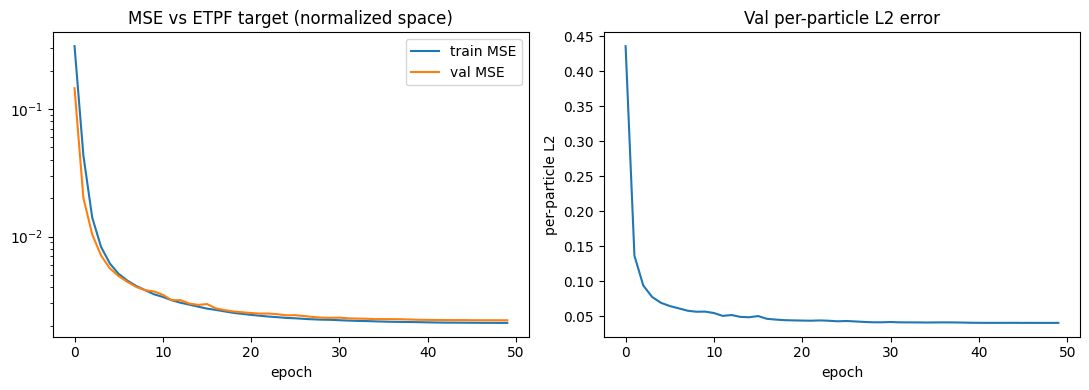

In [6]:
import json, matplotlib.pyplot as plt
with open(log_path) as f:
    log = json.load(f)

epochs = [e['epoch'] for e in log]
train_mse = [e['train_mse'] for e in log]
val_mse = [e['val_mse'] for e in log]
val_l2 = [e['val_l2'] for e in log]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(epochs, train_mse, label='train MSE')
axes[0].plot(epochs, val_mse, label='val MSE')
axes[0].set_yscale('log'); axes[0].set_xlabel('epoch'); axes[0].legend()
axes[0].set_title('MSE vs ETPF target (normalized space)')

axes[1].plot(epochs, val_l2)
axes[1].set_xlabel('epoch'); axes[1].set_ylabel('per-particle L2')
axes[1].set_title('Val per-particle L2 error')

plt.tight_layout(); plt.show()


## 5. Phase 3: Evaluation


### 5.1 Test-set metrics


In [7]:
from evaluation.eval_option_b import evaluate_file

test_metrics_path = os.path.join(LOG_DIR, f'test_metrics_N{N}_d{d}.json')
test_result = evaluate_file(
    data_path=DATA_DIR,
    ckpt_dir=CKPT_DIR,
    out_path=test_metrics_path,
    batch_size=32,
    split='test', N=N, d=d, log10_eps_grid=log10_eps_grid,
)
print('\nPer-epsilon MSE:')
for k, v in test_result['per_eps'].items():
    print(f'  {k}: mse={v["mse"]:.5f},  l2={v["per_particle_l2"]:.5f}')


Loading data from /content/drive/MyDrive/mgn_ot_operator/data
Loading 1 file(s) for split 'test':
  test_N1000_d2__20260422_215722.npz: 1000 clouds
  Merged total: 1000 clouds
  n_clouds=1000, N=1000, d=2, n_eps=3
Restoring from best: /content/drive/MyDrive/mgn_ot_operator/checkpoints_option_b/best/ckpt-82
Running evaluation ...
Saved metrics to /content/drive/MyDrive/mgn_ot_operator/logs_option_b/test_metrics_N1000_d2.json

Aggregate metrics:
  mse                           : 0.00213
  per_particle_l2               : 0.04089
  transport_cost_pred           : 0.06011
  transport_cost_target         : 0.06112
  sinkhorn_divergence           : 0.00662

Per-epsilon MSE:
  log10_eps_-0.500: mse=0.00279,  l2=0.04567
  log10_eps_-0.300: mse=0.00152,  l2=0.02939
  log10_eps_-0.120: mse=0.00209,  l2=0.04761


### 5.2 Per-epsilon plot


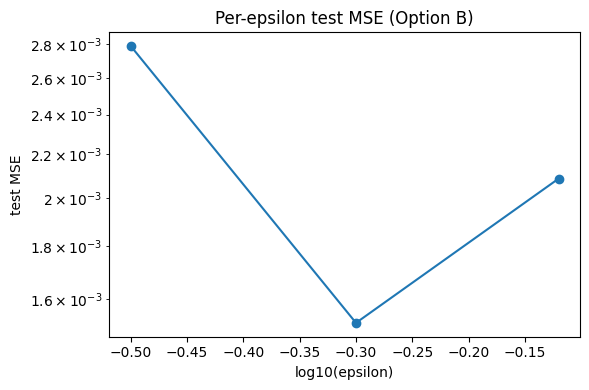

In [8]:
log10_eps_vals = sorted(
    [float(k.replace('log10_eps_', '')) for k in test_result['per_eps']]
)
mses = [test_result['per_eps'][f'log10_eps_{e:.3f}']['mse'] for e in log10_eps_vals]

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(log10_eps_vals, mses, 'o-')
ax.set_xlabel('log10(epsilon)'); ax.set_ylabel('test MSE')
ax.set_yscale('log')
ax.set_title('Per-epsilon test MSE (Option B)')
plt.tight_layout(); plt.show()


### 5.3 Visualize a predicted map


Loading 1 file(s) for split 'test':
  test_N1000_d2__20260422_215722.npz: 1000 clouds
  Merged total: 1000 clouds


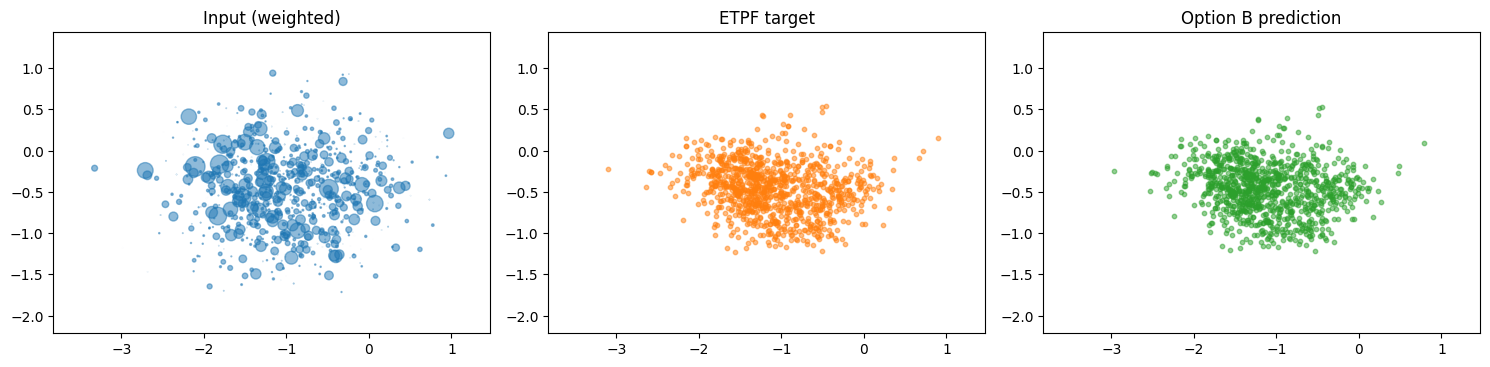

In [9]:
import numpy as np
from data.dataset import load_split

test_split = load_split(DATA_DIR, split='test', N=N, d=d,
                        log10_eps_grid=log10_eps_grid)
k = 0
e_idx = len(test_split['log10_eps_grid']) // 2
log_eps = np.float32(test_split['log10_eps_grid'][e_idx] * np.log(10.0))

x_np = test_split['x'][k]; w_np = test_split['w'][k]
center = test_split['center'][k]; scale = test_split['scale'][k]
y_tilde_tgt = test_split['y_tilde'][k, e_idx]
y_tgt = scale * y_tilde_tgt + center

x = tf.constant(test_split['x'][k:k+1])
w = tf.constant(test_split['w'][k:k+1])
y_pred = operator((x, w, tf.constant([log_eps]))).numpy()[0]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].scatter(x_np[:, 0], x_np[:, 1],
                s=200*w_np/w_np.max(), alpha=0.5)
axes[0].set_title('Input (weighted)')

axes[1].scatter(y_tgt[:, 0], y_tgt[:, 1], s=10, alpha=0.5, c='tab:orange')
axes[1].set_title('ETPF target')

axes[2].scatter(y_pred[:, 0], y_pred[:, 1], s=10, alpha=0.5, c='tab:green')
axes[2].set_title('Option B prediction')

all_pts = np.concatenate([x_np, y_tgt, y_pred])
xl = (all_pts[:, 0].min()-0.5, all_pts[:, 0].max()+0.5)
yl = (all_pts[:, 1].min()-0.5, all_pts[:, 1].max()+0.5)
for ax in axes:
    ax.set_xlim(xl); ax.set_ylim(yl); ax.set_aspect('equal')
plt.tight_layout(); plt.show()


### 5.4 Coupling matrix visualization

The predicted pi for one cloud. Column sums should equal 1/N exactly
(enforced by column softmax); row sums should be approximately w.


pi shape: (1000, 1000)
col sum stats: min=1.0000e-03, max=1.0000e-03, mean=1.0000e-03  (target 1/N=1.0000e-03)
row sum vs w: max |row_sum - w| = 3.2701e-03


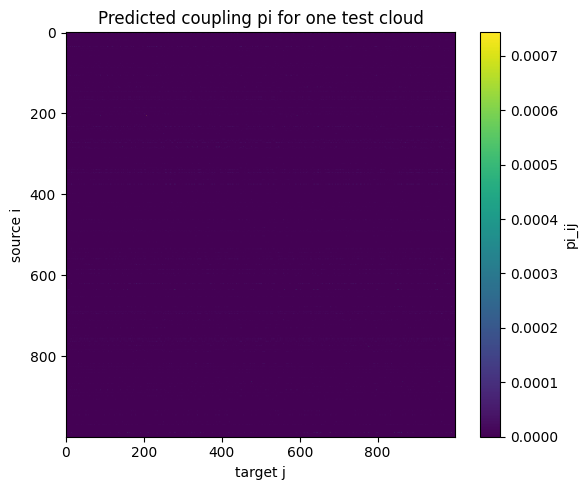

In [12]:
# Recompute with pi.
y_tilde_pred, cen, scl, pi = operator.forward_normalized(
    (x, w, tf.constant([log_eps])), training=False)
pi_np = pi.numpy()[0]  # (N, N)

print(f'pi shape: {pi_np.shape}')
print(f'col sum stats: min={pi_np.sum(0).min():.4e}, max={pi_np.sum(0).max():.4e}, '
      f'mean={pi_np.sum(0).mean():.4e}  (target 1/N={1/pi_np.shape[0]:.4e})')
print(f'row sum vs w: max |row_sum - w| = '
      f'{np.abs(pi_np.sum(1) - test_split["w"][k]).max():.4e}')

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(pi_np, aspect='auto', cmap='viridis')
plt.colorbar(im, ax=ax, label='pi_ij')
ax.set_xlabel('target j'); ax.set_ylabel('source i')
ax.set_title('Predicted coupling pi for one test cloud')
plt.tight_layout(); plt.show()


Loading 1 file(s) for split 'test':
  test_N1000_d2__20260422_215722.npz: 1000 clouds
  Merged total: 1000 clouds


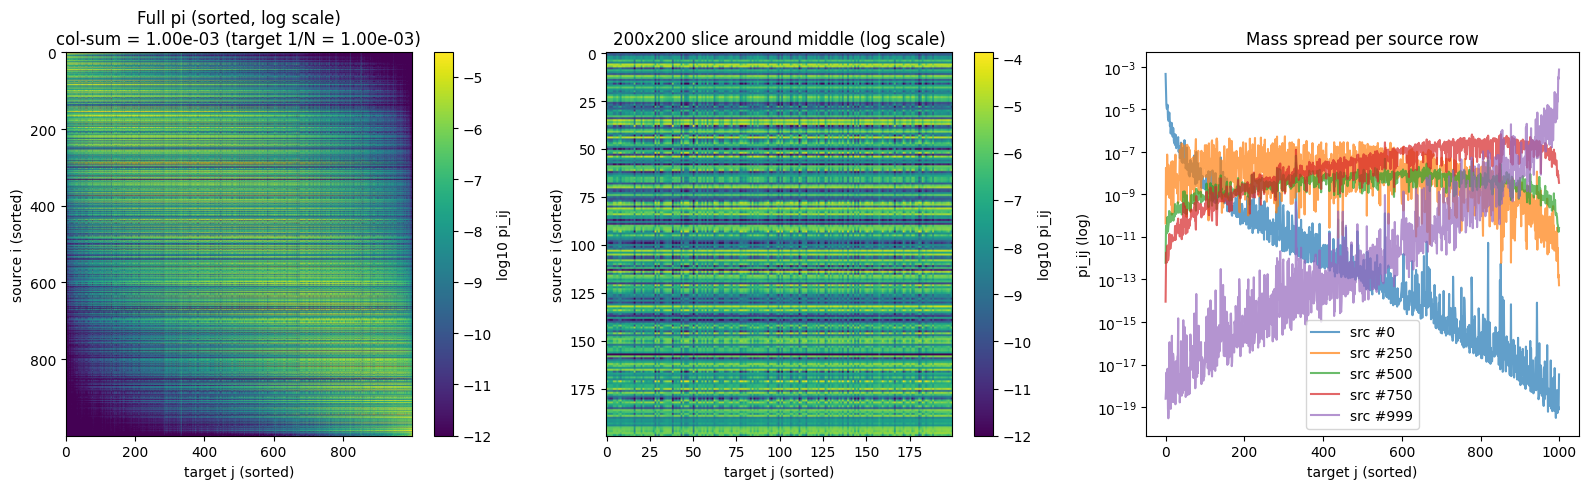

Entries above 1e-5: 24998/1000000 = 2.5%
Effective entries per source (>1e-5): 25.0
Max pi entry: 7.4298e-04
Min row sum (target marginal exact?): 1.0000e-03
Max row sum: 1.0000e-03
Source marginal (should match w):
  max |row_sum - w|: 3.2701e-03


In [13]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from data.dataset import load_split

test_split = load_split(DATA_DIR, split='test', N=N, d=d, log10_eps_grid=log10_eps_grid)

k = 0
e_idx = 1   # middle eps
log_eps = np.float32(test_split['log10_eps_grid'][e_idx] * np.log(10.0))

x = tf.constant(test_split['x'][k:k+1])
w = tf.constant(test_split['w'][k:k+1])

# Get prediction with coupling
y_tilde_pred, center, scale, pi = operator.forward_normalized(
    (x, w, tf.constant([log_eps])), training=False)
pi_np = pi.numpy()[0]   # (N, N)
x_np = test_split['x'][k]
w_np = test_split['w'][k]

# --- Sort source and target indices by x-coordinate so the coupling
# --- shows its near-diagonal band structure.
src_order = np.argsort(x_np[:, 0])
# Target shares support with source so use same ordering for jth particle.
tgt_order = src_order
pi_sorted = pi_np[src_order, :][:, tgt_order]

# --- Plot: log scale + zoomed slice
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# (a) full matrix, log scale
log_pi = np.log10(np.maximum(pi_sorted, 1e-12))
im0 = axes[0].imshow(log_pi, aspect='auto', cmap='viridis',
                     vmin=np.percentile(log_pi, 5),
                     vmax=np.percentile(log_pi, 99.5))
axes[0].set_title(f'Full pi (sorted, log scale)\n'
                  f'col-sum = {pi_np.sum(0).mean():.2e} (target 1/N = {1/N:.2e})')
axes[0].set_xlabel('target j (sorted)'); axes[0].set_ylabel('source i (sorted)')
plt.colorbar(im0, ax=axes[0], label='log10 pi_ij')

# (b) zoomed 200x200 corner around the middle
mid = N // 2
sl = slice(mid - 100, mid + 100)
im1 = axes[1].imshow(log_pi[sl, sl], aspect='auto', cmap='viridis')
axes[1].set_title(f'200x200 slice around middle (log scale)')
axes[1].set_xlabel('target j (sorted)'); axes[1].set_ylabel('source i (sorted)')
plt.colorbar(im1, ax=axes[1], label='log10 pi_ij')

# (c) row distribution: for source 0 in sorted order, how does its mass distribute?
sample_rows = [0, N // 4, N // 2, 3 * N // 4, N - 1]
for i in sample_rows:
    axes[2].plot(pi_sorted[i, :], label=f'src #{i}', alpha=0.7)
axes[2].set_yscale('log')
axes[2].set_xlabel('target j (sorted)'); axes[2].set_ylabel('pi_ij (log)')
axes[2].set_title('Mass spread per source row')
axes[2].legend()

plt.tight_layout()
plt.show()

# Diagnostics: sparsity
n_significant = (pi_np > 1e-5).sum()
total = N * N
print(f'Entries above 1e-5: {n_significant}/{total} = {100*n_significant/total:.1f}%')
print(f'Effective entries per source (>1e-5): {n_significant/N:.1f}')
print(f'Max pi entry: {pi_np.max():.4e}')
print(f'Min row sum (target marginal exact?): {pi_np.sum(0).min():.4e}')
print(f'Max row sum: {pi_np.sum(0).max():.4e}')
print(f'Source marginal (should match w):')
print(f'  max |row_sum - w|: {np.abs(pi_np.sum(1) - w_np).max():.4e}')

### 5.5 Speedup benchmark

Wall-clock comparison between Option B operator forward and direct
GPU-batched Sinkhorn at the same eps.


In [14]:
import time
from data.sinkhorn_targets import etpf_targets_normalized

def benchmark(operator, N, d, eps, batch_size, n_warmup=5, n_trials=20):
    rng = np.random.default_rng(0)
    x_np = rng.normal(size=(batch_size, N, d)).astype(np.float32)
    w_np = rng.random((batch_size, N)).astype(np.float32)
    w_np = w_np / w_np.sum(axis=-1, keepdims=True)
    x_t = tf.constant(x_np); w_t = tf.constant(w_np)
    le = tf.fill((batch_size,), np.float32(np.log(eps)))
    eps_b = tf.fill((batch_size,), np.float32(eps))

    @tf.function
    def op_fwd(x_, w_, le_):
        return operator((x_, w_, le_), training=False)

    def sk_fwd(x_, w_, eps_):
        y, _ = etpf_targets_normalized(x_, w_, eps_, n_iters=1000)
        return y

    for _ in range(n_warmup):
        _ = op_fwd(x_t, w_t, le)
        _ = sk_fwd(x_t, w_t, eps_b)

    t0 = time.time()
    for _ in range(n_trials):
        y = op_fwd(x_t, w_t, le)
    _ = y.numpy()
    t_op = (time.time() - t0) / n_trials * 1000

    t0 = time.time()
    for _ in range(n_trials):
        y = sk_fwd(x_t, w_t, eps_b)
    _ = y.numpy()
    t_sk = (time.time() - t0) / n_trials * 1000
    return {'operator_ms': t_op, 'sinkhorn_ms': t_sk, 'speedup': t_sk/t_op}

for bs in [1, 8, 32, 128]:
    r = benchmark(operator, N=N, d=d, eps=0.5, batch_size=bs)
    print(f'B={bs:3d}: op={r["operator_ms"]:.2f} ms, '
          f'sinkhorn={r["sinkhorn_ms"]:.2f} ms, '
          f'speedup={r["speedup"]:.2f}x')


B=  1: op=2.93 ms, sinkhorn=330.45 ms, speedup=112.69x
B=  8: op=2.82 ms, sinkhorn=870.39 ms, speedup=308.61x
B= 32: op=3.78 ms, sinkhorn=2100.84 ms, speedup=555.45x
B=128: op=14.13 ms, sinkhorn=6960.36 ms, speedup=492.63x


## Notes

- Option B checkpoints live at `CKPT_DIR = {drive_root}/checkpoints_option_b/`,
  distinct from the M-MGN pipeline. The two can coexist on Drive.
- The precomputed `.npz` files are shared; both operators consume the
  same normalized-space ETPF targets.
- If Phase 1 overfit reaches much lower MSE than M-MGN (say 1e-5 or below
  for single cloud), the class-mismatch diagnosis is confirmed and we
  should proceed with Option B as the canonical operator.
- If Phase 1 plateaus near M-MGN's floor, something else is going on
  and we'd want to re-examine the targets or architecture.
